In [4]:
import os
import random
from collections import defaultdict

import torch
from torchvision import datasets, transforms
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset
from torch.nn import CrossEntropyLoss
from torch.optim import SGD
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score
import ml_insights as mli
from splinecalib import SplineCalib

Loading trained model

  Mean: [0.35206928849220276, 0.3834707736968994, 0.2852235436439514]
  Std:  [0.14356152713298798, 0.12388855963945389, 0.12525705993175507]
Used device : cpu
Classes : ['damage', 'no_damage']
Number of images (train) : 19000
Number of images (val) : 2000
Number of images (test) : 2000


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


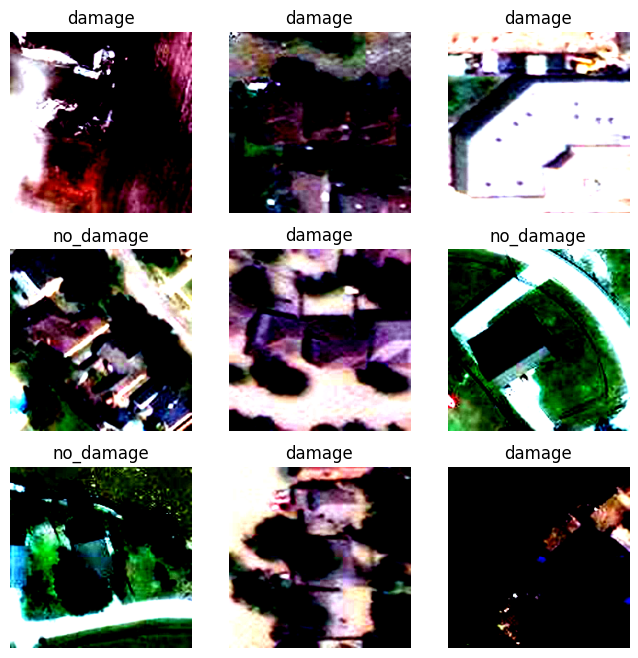

In [5]:
from data_utils import compute_normalization_stats

base_dir = "ipeo_hurricane_for_students"

#Compute normalization statistics from training set using the function defined in data_utils.py
mean, std = compute_normalization_stats(base_dir, split="train")

#Define normalization transform using computed mean and std from training set
normalize = T.Normalize(mean, std)

#Define default transform for datasets with the good size for model and normalization
default_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    normalize
])

#Load datasets with defined transform
train_ds = datasets.ImageFolder(os.path.join(base_dir, "train"), transform=default_transform)
val_ds   = datasets.ImageFolder(os.path.join(base_dir, "validation"), transform=default_transform)
test_ds  = datasets.ImageFolder(os.path.join(base_dir, "test"), transform=default_transform)

#Detection of device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Used device :", device)


# DataLoader configuration
batch_size = 16
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=batch_size, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=batch_size, num_workers=2)

#Print dataset information
print("Classes :", train_ds.classes)
print("Number of images (train) :", len(train_ds))
print("Number of images (val) :", len(val_ds))
print("Number of images (test) :", len(test_ds))

#Function to display a batch of images from a DataLoader
def show_batch(loader):
    """Display a batch of images from the given DataLoader"""
    images, labels = next(iter(loader))
    fig, axes = plt.subplots(3, 3, figsize=(8, 8))
    for img, label, ax in zip(images[:9], labels[:9], axes.flat):
        ax.imshow(img.permute(1, 2, 0))
        ax.set_title(train_ds.classes[label])
        ax.axis("off")
    plt.show()

show_batch(train_loader)

Load Resnet model (resnet_test ok?)

In [6]:
#Using 2 deep learning modele, resnet34 and mobilenet_v3_small
from torchvision.models import resnet34

#load a resnet34 with 2 classes (damage vs no_damage) and move to device
model_resnet = resnet34(num_classes=2).to(device)
# load existing model
model_resnet.load_state_dict(torch.load("models/resnet_final.pth", map_location=device))

C:\Users\aurel\AppData\Local\Temp\ipykernel_19340\2129229754.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_resnet.load_state_dict(torch.load("models/resnet_final

<All keys matched successfully>

SplineCalib

Get the model probabilities (uncalibrated)

In [ ]:
def get_probs_labels(model, loader, device):
    """Get predicted probabilities (for 'damage') and true labels from a DataLoader"""
    model.eval()
    probs_list = []
    labels_list = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)               # shape: (batch_size, 2)
            probs = torch.softmax(logits, dim=1)[:, 1]  # probability of 'damage'

            probs_list.append(probs.cpu())
            labels_list.append(y.cpu())

    probs_all = torch.cat(probs_list).numpy()
    labels_all = torch.cat(labels_list).numpy()

    return probs_all, labels_all

# Calibration set (=validation set)
X_calib, y_calib = get_probs_labels(model_resnet, val_loader, device)

# Test set
X_test, y_test = get_probs_labels(model_resnet, test_loader, device)



TEST CODE BEFORE FIXING MODEL ---------------------

In [5]:
def get_probs_labels(model, loader, device):
    """Get predicted probabilities (for 'damage') and true labels from a DataLoader"""
    model.eval()
    probs_list = []
    labels_list = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model_resnet(x)
            logits_rescaled = logits / 7  # reduce magnitude temporarily
            probs_rescaled = torch.softmax(logits_rescaled, dim=1)[:,1]

            probs_list.append(probs_rescaled.cpu())
            labels_list.append(y.cpu())
        print(probs_rescaled[:10])

    probs_all = torch.cat(probs_list).numpy()
    labels_all = torch.cat(labels_list).numpy()

    return probs_all, labels_all

# Calibration set (=validation set)
X_calib, y_calib = get_probs_labels(model_resnet, val_loader, device)

# Test set
X_test, y_test = get_probs_labels(model_resnet, test_loader, device)


tensor([0.5676, 0.7654, 0.7034, 0.6986, 0.7310, 0.7757, 0.5484, 0.6942, 0.6218,
        0.5608])
tensor([0.7382, 0.5629, 0.7791, 0.6525, 0.6383, 0.6424, 0.7022, 0.6484, 0.6413,
        0.6693])


----------------------------------------------------

Create calibration model and fit to calibration set

In [ ]:
# Define SplineCalib object
calib1 = mli.SplineCalib()


# Fit the calibrator on the validation set probabilities
calib1.fit(X_calib, y_calib)

# Calibrated probabilities on test set
preds_test_calib = calib1.predict(X_test)

# Uncalibrated probabilities (for comparison)
preds_test_uncalib = X_test

preds_test_uncalib[:10]

for x, y in val_loader:
    logits = model_resnet(x.to(device))
    print(logits[:10])
    break

c:\Users\aurel\anaconda3_bis\envs\DeepLearning\Lib\site-packages\scipy\optimize\_optimize.py:74: RuntimeWarning: overflow encountered in exp
  fg = self.fun(x, *args)


tensor([[ 2.7777, -3.1939],
        [ 5.3371, -5.8318],
        [ 5.4687, -5.6451],
        [ 5.5154, -5.8210],
        [ 3.5387, -3.7797],
        [ 7.5518, -8.1175],
        [ 5.4901, -5.9269],
        [ 0.3958, -0.8988],
        [ 1.0918, -1.3831],
        [ 2.5160, -2.9761]], grad_fn=<SliceBackward0>)


Compare performance of calibrated and uncalibrated models

ROC AUC - uncalibrated: 0.9998
ROC AUC - calibrated  : 0.9998


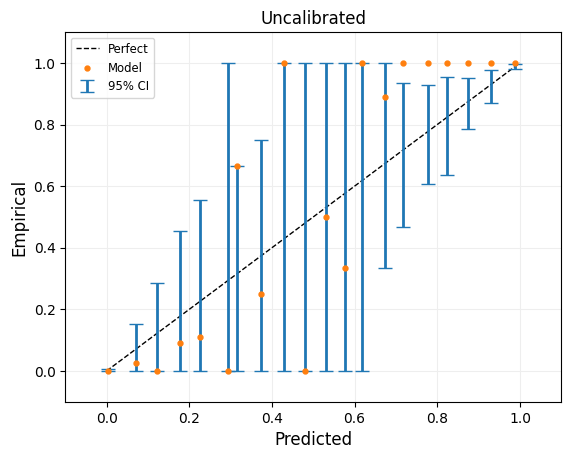

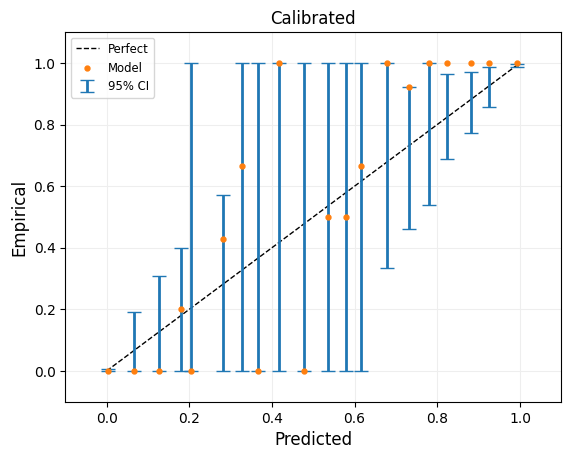

In [ ]:
# ROC AUC
roc_uncalib = roc_auc_score(y_test, preds_test_uncalib)
roc_calib   = roc_auc_score(y_test, preds_test_calib)

print(f"ROC AUC - uncalibrated: {roc_uncalib:.4f}")
print(f"ROC AUC - calibrated  : {roc_calib:.4f}")

# Reliability diagrams
plt.figure()
mli.plot_reliability_diagram(y_test, preds_test_uncalib, marker='.')

plt.title("Uncalibrated")
plt.show()

plt.figure()
mli.plot_reliability_diagram(y_test, preds_test_calib, marker='.')

plt.title("Calibrated")
plt.show()



In [17]:
calib1.show_spline_reg_plot()

NameError: name 'calib1' is not defined

In [9]:

## Compare the log_loss values
log_loss(y_test, preds_test_uncalib),log_loss(y_test, preds_test_calib)

(0.18755707891699114, 0.022009182346173224)

Save calib object to disk

In [ ]:
import joblib
joblib.dump(calib1, 'calib1.pkl')

Temperature Scaling

In [ ]:
def get_logits_labels(model, loader, device):
    model.eval()
    logits_list = []
    labels_list = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)              # shape: (N, 2)
            logits_list.append(logits.cpu())
            labels_list.append(y.cpu())

    logits_all = torch.cat(logits_list).numpy()
    labels_all = torch.cat(labels_list).numpy()

    return logits_all, labels_all


In [ ]:
logits_calib, y_calib = get_logits_labels(model_resnet, val_loader, device)
logits_test,  y_test  = get_logits_labels(model_resnet, test_loader, device)

# positive-class logits
z_calib = torch.tensor(logits_calib[:, 1], dtype=torch.float32)
z_test  = torch.tensor(logits_test[:, 1],  dtype=torch.float32)
y_calib = torch.tensor(y_calib, dtype=torch.float32)


In [ ]:
import torch.nn.functional as F

# temperature parameter (initialized at 1)
log_T = torch.zeros(1, requires_grad=True)

optimizer = torch.optim.LBFGS([log_T], lr=0.01, max_iter=50)

def closure():
    optimizer.zero_grad()
    T = torch.exp(log_T)
    loss = F.binary_cross_entropy_with_logits(z_calib / T, y_calib)
    loss.backward()
    return loss

optimizer.step(closure)

T = torch.exp(log_T).item()
print("Learned temperature:", T)


In [ ]:
probs_test_cal = torch.sigmoid(z_test / T).numpy()
probs_test_uncal = torch.sigmoid(z_test).numpy()


In [ ]:
# ROC AUC
roc_uncalib = roc_auc_score(y_test, probs_test_uncal)
roc_calib   = roc_auc_score(y_test, probs_test_cal)

print(f"ROC AUC - uncalibrated: {roc_uncalib:.4f}")
print(f"ROC AUC - calibrated  : {roc_calib:.4f}")

# Reliability diagrams
plt.figure()
mli.plot_reliability_diagram(y_test, probs_test_uncal, marker='.')

plt.title("Uncalibrated")
plt.show()

plt.figure()
mli.plot_reliability_diagram(y_test, probs_test_cal, marker='.')

plt.title("Calibrated")
plt.show()



Compare SplineCalib to Isotonic Regression, Platt Scaling and Beta Calibration.

In [ ]:
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from betacal import BetaCalibration

In [ ]:
# Fit three-parameter beta calibration
bc = BetaCalibration(parameters="abm")
bc.fit(cv_preds_train_calib[:,1], y_train_calib)

# Fit Isotonic Regression
iso = IsotonicRegression()
iso.fit(cv_preds_train_calib[:,1], y_train_calib)

# Fit Platt scaling (logistic calibration)
lr = LogisticRegression(C=99999999999)
lr.fit(cv_preds_train_calib[:,1].reshape(-1,1), y_train_calib)

In [ ]:
tvec = np.linspace(0,1,1001)
bc_probs = bc.predict(tvec)
iso_probs = iso.predict(tvec)
platt_probs = lr.predict_proba(tvec.reshape(-1,1))[:,1]
splinecalib_probs = calib3.calibrate(tvec)
#calib3.show_calibration_curve()
mli.plot_reliability_diagram(y_train_calib, cv_preds_train_calib[:,1], error_bars=False);
plt.plot(tvec, splinecalib_probs, label='SplineCalib')
plt.plot(tvec, bc_probs, label='Beta')
plt.plot(tvec, iso_probs, label='Isotonic')
plt.plot(tvec, platt_probs, label='Platt')
plt.legend()
plt.title('Calibration Curves for different methods');

In [ ]:
preds_test_bc = bc.predict(preds_test_2_uncalib)
preds_test_iso = iso.predict(preds_test_2_uncalib)
preds_test_platt = lr.predict_proba(preds_test_2_uncalib.reshape(-1,1))[:,1]
preds_test_splinecalib = calib3.calibrate(preds_test_2_uncalib)

bc_loss = log_loss(y_test, preds_test_bc)
iso_loss = log_loss(y_test, preds_test_iso)
platt_loss = log_loss(y_test, preds_test_platt)
splinecalib_loss = log_loss(y_test, preds_test_splinecalib)

print('Platt loss       = {}'.format(np.round(platt_loss,5)))
print('Beta Calib loss  = {}'.format(np.round(bc_loss,5)))
print('Isotonic loss    = {}'.format(np.round(iso_loss,5)))
print('SplineCalib loss = {}'.format(np.round(splinecalib_loss,5)))